# Models calibration

## Model and data upload

In [1]:
from pathlib import Path

MODELS_DIR = Path().resolve().parent / "models"
print(MODELS_DIR)

C:\Users\jhquiza\repos\proyecto-riesgos\default\models


In [2]:
import joblib

lgb_model = joblib.load(MODELS_DIR / "lgb_model.joblib")

In [ ]:
import pandas as pd

# Cargar el dataset
DATA_DIR = Path().resolve().parent.parent / "data" / "data-09-2025"
data_file = "cleaned_data_default.parquet"

df = pd.read_parquet(DATA_DIR / data_file)
df


,plazo,vinculacion,v_cuota,v_prestamo,s_capital,s_intereses,aportes,garantias,valorgarantia,ctasahorros,...,actividadeconomica,estado_cliente,departamento,sexo,curtotalingresos,curtotalegresos,intestrato,actualizacion,default,puntaje_data
n_credito,,,,,,,,,,,,,,,,,,,,,
003-002-0125852-7,1827,8103,356849.0,15000000.0,12923538.0,123855,7741255,1,7741255,33042953.0,...,asalariados,1,antioquia,0,4597000.0,1500000.0,5.0,1,0,795.0
004-002-0068475-5,1826,1434,2650409.0,100460000.0,31911361.0,263265,4601706,1,4601706,3791115.0,...,asalariados,1,antioquia,0,4597000.0,650000.0,5.0,1,0,836.0
003-002-0122592-9,1826,573,791482.0,30000000.0,23844684.0,261477,530431,1,530431,94435.0,...,asalariados,1,antioquia,0,4400000.0,2000000.0,4.0,0,1,709.0
006-002-0023879-0,2922,1902,2860501.0,176000000.0,113842595.0,1008570,3023534,2,320385440,54841.0,...,educacion_basica_secundaria,1,antioquia,0,22020000.0,1500000.0,4.0,1,0,733.0
006-002-0026159-4,2557,1902,987637.0,50300000.0,38521256.0,317167,1023082,2,320385440,54841.0,...,educacion_basica_secundaria,1,antioquia,0,22020000.0,1500000.0,4.0,1,0,695.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
006-002-0030353-0,1096,912,168702.0,4300000.0,3455366.0,43407,698776,1,698776,826221.0,...,asalariados,1,antioquia,0,1173816.0,700000.0,2.0,0,0,452.0
002-002-0134113-5,731,449,263573.0,5100000.0,2513703.0,31592,699181,1,699181,136309.0,...,asalariados,1,antioquia,1,2325000.0,500000.0,3.0,1,0,676.0
002-002-0118188-8,2556,2808,620029.0,30000000.0,17299268.0,209025,2008212,1,4794572,213091.0,...,asalariados,1,antioquia,0,5303000.0,550000.0,2.0,0,0,610.0


In [ ]:
from sklearn.model_selection import train_test_split

df = df.dropna()

X = df.drop(columns=["default", "s_capital"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (10280, 20)
Testing set size: (2570, 20)


In [5]:
y_prob = lgb_model.predict_proba(X_test)[:, 1]

[LightGBM] [Warning] feature_fraction is set=0.6149544953087348, colsample_bytree=0.5143984459906721 will be ignored. Current value: feature_fraction=0.6149544953087348
[LightGBM] [Warning] lambda_l1 is set=0.3747784362449289, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.3747784362449289
[LightGBM] [Warning] lambda_l2 is set=0.0053082886810172, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0053082886810172
[LightGBM] [Warning] bagging_fraction is set=0.914826887986507, subsample=1.0 will be ignored. Current value: bagging_fraction=0.914826887986507
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1


## ROC and precision-recall curves

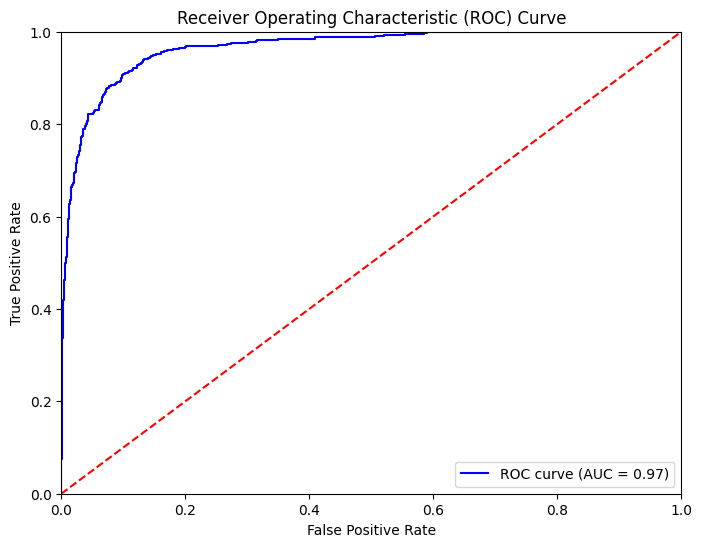

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

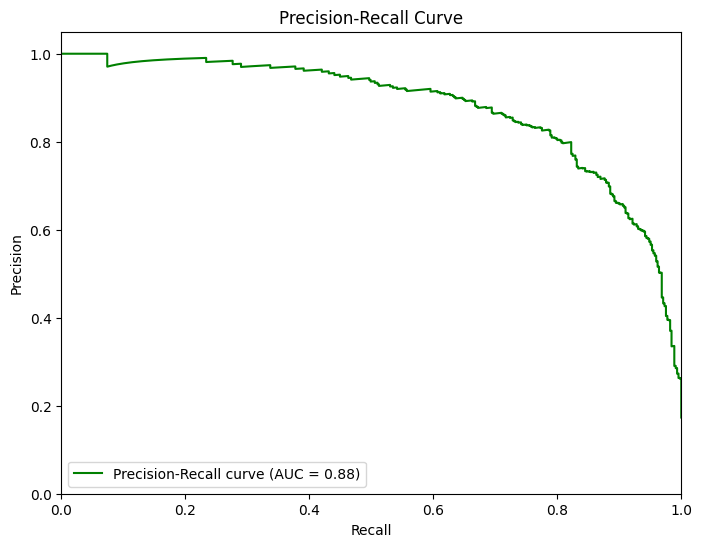

In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color="green", label=f"Precision-Recall curve (AUC = {pr_auc:.2f})")  # noqa: E501
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()

## Model calibration

[LightGBM] [Warning] feature_fraction is set=0.6149544953087348, colsample_bytree=0.5143984459906721 will be ignored. Current value: feature_fraction=0.6149544953087348
[LightGBM] [Warning] lambda_l1 is set=0.3747784362449289, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.3747784362449289
[LightGBM] [Warning] lambda_l2 is set=0.0053082886810172, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0053082886810172
[LightGBM] [Warning] bagging_fraction is set=0.914826887986507, subsample=1.0 will be ignored. Current value: bagging_fraction=0.914826887986507
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.6149544953087348, colsample_bytree=0.5143984459906721 will be ignored. Current value: feature_fraction=0.6149544953087348
[LightGBM] [Warning] lambda_l1 is set=0.3747784362449289, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.3747784362449289
[LightGBM

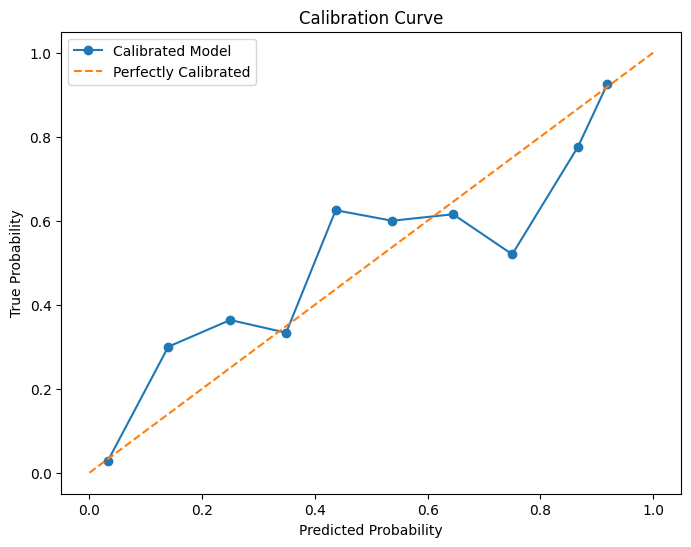

In [10]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

 # --- Calibración ---
frozen_lgb_model = FrozenEstimator(lgb_model)

calibrated_clf = CalibratedClassifierCV(
    frozen_lgb_model,     
    method="sigmoid",
    cv=None,
    ensemble=False,
    )

calibrated_clf.fit(X_test, y_test)

# Predicciones calibradas
y_pred_calib = calibrated_clf.predict(X_test)
y_proba_calib = calibrated_clf.predict_proba(X_test)[:, 1]

# Curva de calibración
prob_true, prob_pred = calibration_curve(y_test, y_proba_calib, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Calibrated Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly Calibrated")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

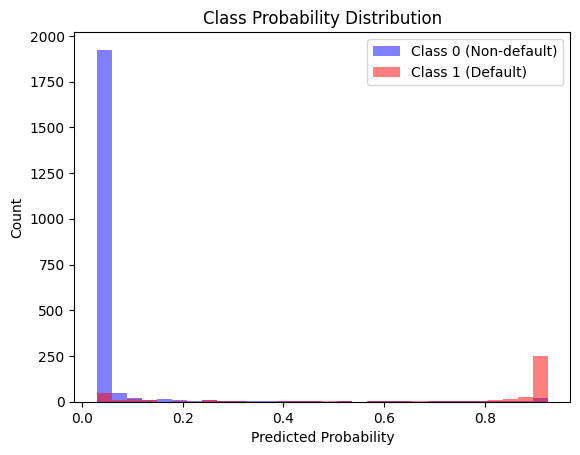

In [11]:
plt.hist(
y_proba_calib[y_test == 0],
bins=30,
alpha=0.5,
label="Class 0 (Non-default)",
color="blue",
)
plt.hist(
y_proba_calib[y_test == 1],
bins=30,
alpha=0.5,
label="Class 1 (Default)",
color="red",
)
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Class Probability Distribution")
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

print("reporte de clasificación:")
print(classification_report(y_test, y_pred_calib), "\n")
print("matriz de confusión:")
print(confusion_matrix(y_test, y_pred_calib), "\n")

reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2125
           1       0.84      0.75      0.79       445

    accuracy                           0.93      2570
   macro avg       0.89      0.86      0.88      2570
weighted avg       0.93      0.93      0.93      2570
 

matriz de confusión:
[[2061   64]
 [ 111  334]] 

